In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df= pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [52]:
X=df[['displacement']]
y=df['mpg']

print("Missing values in ", X.isnull().sum())
print("Missing values in mpg:", y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values in mpg: 0


In [53]:
df[['displacement', 'mpg']].dropna()

X=df[['displacement']]
y=df['mpg']

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


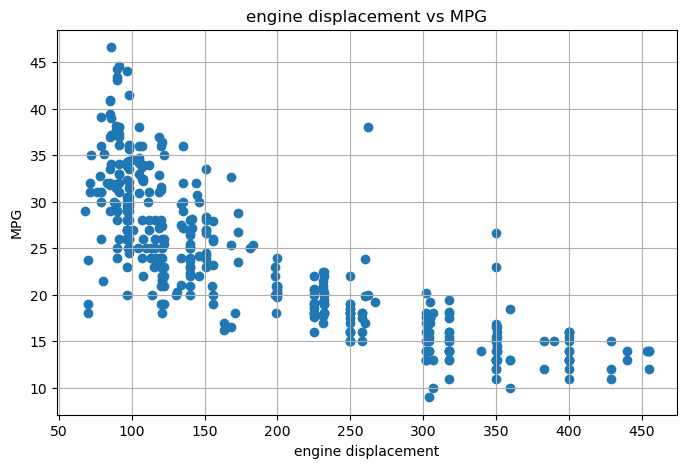

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.xlabel('engine displacement')
plt.ylabel('MPG')
plt.title('engine displacement vs MPG')
plt.grid(True)
plt.show()

In [56]:
X_test,X_train, y_test, y_train = train_test_split(
    X,
    y,
    test_size=0.8,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 319
Testing samples: 79


In [57]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [58]:
mse_linear=mean_squared_error(y_test,y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("linear regression results")
print("-----------------------------------")
print("MSE:",mse_linear)
print("R2 Score:",r2_linear)

linear regression results
-----------------------------------
MSE: 20.424631236588176
R2 Score: 0.6557289102156161


In [59]:
results=[]

polynomial_models={}

results.append({
    'model':'linear regression',
    'degree': 1,
    'MSE' : mse_linear,
    'R_sqaured': r2_linear
})

for degree in range(2,6):
    poly=PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model= LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly= poly_model.predict(X_test_poly)

    mse= mean_squared_error(y_test, y_pred_poly)
    r2=r2_score(y_test,y_pred_poly)

    results.append({
    'model':'polynomial regression',
    'degree': degree,
    'MSE' : mse,
    'R_sqaured': r2
    })

    polynomial_models[degree]= {
        'poly': poly,
        'model': poly_model
    }

In [60]:
results_df = pd.DataFrame(results)
results_df

,model,degree,MSE,R_sqaured
0,linear regression,1,20.424631,0.655729
1,polynomial regression,2,18.763527,0.683728
2,polynomial regression,3,19.307866,0.674553
3,polynomial regression,4,19.555673,0.670376
4,polynomial regression,5,19.474182,0.671749


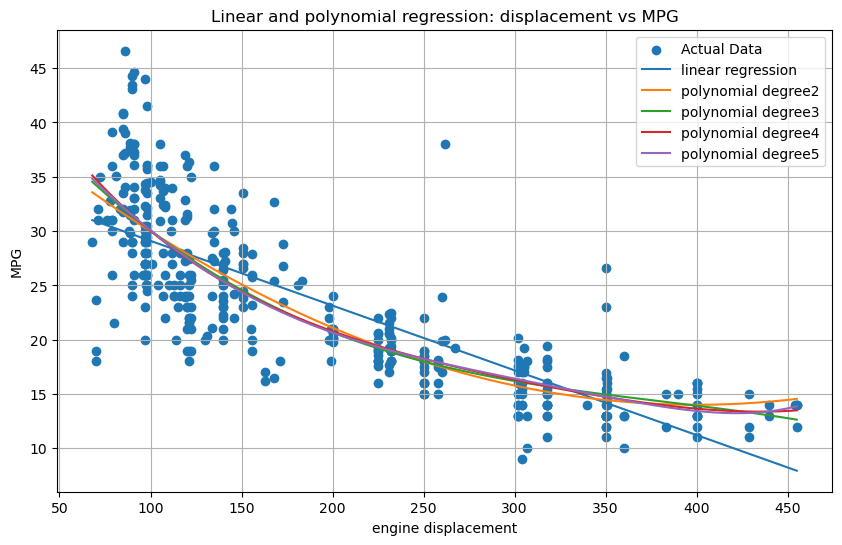

In [61]:
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})


plt.figure(figsize=(10,6))
plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)

y_plot_linear= linear_model.predict(X_plot)
plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='linear regression'
)

for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    X_plot_poly= poly.transform(X_plot)
    y_plot_poly = poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'polynomial degree{degree}'
    )

plt.xlabel('engine displacement')
plt.ylabel('MPG')
plt.title('Linear and polynomial regression: displacement vs MPG')

plt.legend()
plt.grid(True)
plt.show()


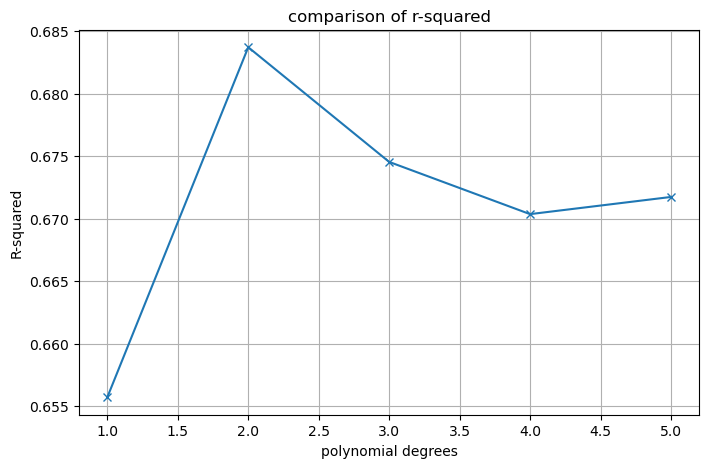

In [62]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['degree'],
    results_df['R_sqaured'],
    marker ='x'
)

plt.xlabel("polynomial degrees")
plt.ylabel("R-squared")
plt.title("comparison of r-squared")

plt.grid(True)
plt.show()